In [1]:
%cd ..

/home/ricka/Git/GitHub/RickArko/kaggle/comp/kcom-pokemon


# Match Analysis — Pokemon TCG Agent Performance

Load aggregated Parquet tables from `make match-all` and explore agent behaviour,
win-rate trends, prize-race dynamics, decision patterns, and deck-type matchups.

## Setup


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA = Path("data/matches/aggregated")

In [3]:
try:
    from pokemon.card_db import get_card_db

    results = pd.read_parquet(DATA / "results.parquet")
    frames = pd.read_parquet(DATA / "frames.parquet")
    turns = pd.read_parquet(DATA / "turn_summary.parquet")
    print(f"results: {len(results)} matches")
    print(f"frames:  {len(frames)} decision points")
    print(f"turns:   {len(turns)} turn-rows")
except FileNotFoundError:
    print("No aggregated data found. Run: make match-all")
    results = frames = turns = None

results: 1800 matches
frames:  15413 decision points
turns:   4908 turn-rows


---
## 1. Win-Rate Matrix

Heatmap of agent A (row) vs agent B (column) win percentages.

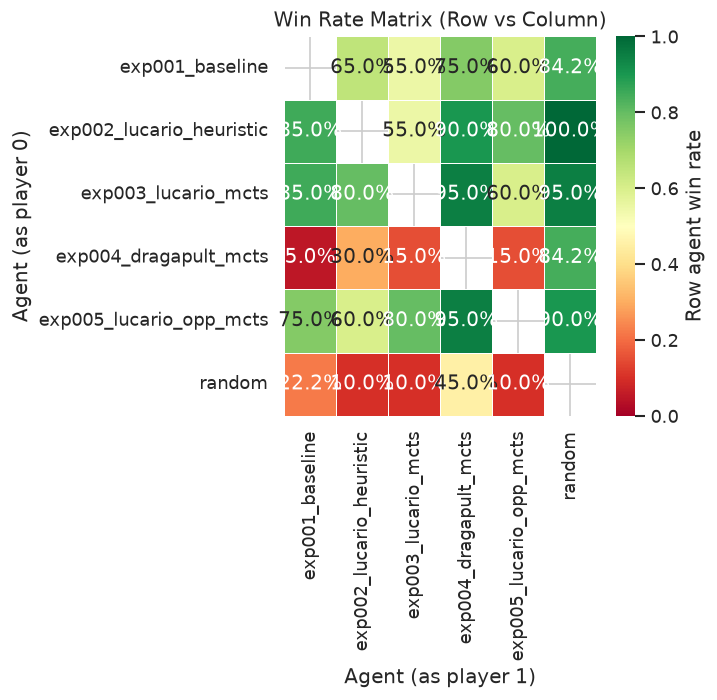

In [4]:
if results is not None:
    wins = results[results["winner"].isin([0, 1])].copy()
    wins["agent0_won"] = (wins["winner"] == 0).astype(int)

    matrix = wins.pivot_table(
        index="agent0", columns="agent1", values="agent0_won", aggfunc="mean"
    )

    plt.figure(figsize=(max(6, len(matrix.columns)), max(4, len(matrix.index))))
    sns.heatmap(matrix, annot=True, fmt=".1%", cmap="RdYlGn", vmin=0, vmax=1,
                linewidths=0.5, cbar_kws={"label": "Row agent win rate"})
    plt.title("Win Rate Matrix (Row vs Column)")
    plt.xlabel("Agent (as player 1)")
    plt.ylabel("Agent (as player 0)")
    plt.tight_layout()
    plt.show()

---
## 2. Deck-Type Matchup Analysis

Cross-tabulate deck archetypes to see which builds counter which.

In [5]:
if results is not None and "arch0" in results.columns:
    valid = results[results["winner"].isin([0, 1])].copy()
    valid["arch0_won"] = (valid["winner"] == 0).astype(int)

    arch_matrix = valid.pivot_table(
        index="arch0", columns="arch1", values="arch0_won", aggfunc=["mean", "count"]
    )

    # Win rate heatmap
    wr = arch_matrix["mean"]
    plt.figure(figsize=(max(6, len(wr.columns)), max(4, len(wr.index))))
    sns.heatmap(wr, annot=True, fmt=".1%", cmap="RdYlGn", vmin=0, vmax=1,
                linewidths=0.5, cbar_kws={"label": "Archetype row win rate"})
    plt.title("Deck Archetype Win Rate Matrix (Row vs Column)")
    plt.xlabel("Opponent Archetype")
    plt.ylabel("My Archetype")
    plt.tight_layout()
    plt.show()

    # Sample counts
    print("Matchups per pair:")
    print(arch_matrix["count"].to_string())
else:
    print("arch0/arch1 not in data. Run 'make match-aggregate' to add deck classification.")

arch0/arch1 not in data. Run 'make match-aggregate' to add deck classification.


### Card Frequency by Archetype

Which cards appear most in winning vs losing decks?

In [6]:
if results is not None and "arch0" in results.columns:
    from pokemon.card_db import get_card_db
    from pokemon.deck_analysis import card_frequencies

    db = get_card_db(use_engine=False)

    # Collect all deck lists grouped by archetype
    decks_by_arch = {}
    for _, row in results.iterrows():
        arch = row.get("arch0", "unknown")
        decks_by_arch.setdefault(arch, [])

    for arch, deck_list in sorted(decks_by_arch.items()):
        if not deck_list:
            continue
        freqs = card_frequencies(deck_list, db, top_n=10)
        print(f"\nTop cards in {arch} ({len(deck_list)} decks):")
        for f in freqs:
            print(f"  {f['card_id']:>5} {f['name']:<30} {f['pct_decks']:>5.1f}% of decks  ({f['total_copies']} copies)")
else:
    print("arch columns not available")

arch columns not available


### Deck Composition Stats

Energy / Pokemon / Trainer split per archetype.

In [7]:
if results is not None and "arch0" in results.columns:
    from pokemon.card_db import get_card_db
    from pokemon.deck_analysis import deck_summary

    db = get_card_db(use_engine=False)

    # Compute composition for each deck in results
    comps = []
    for _, row in results.iterrows():
        for side in ["0", "1"]:
            deck_col = f"deck{side}"
            arch_col = f"arch{side}"
            if deck_col not in results.columns or arch_col not in results.columns:
                continue
            deck = row.get(deck_col)
            if deck is None or not isinstance(deck, list):
                continue
            summary = deck_summary(deck, db)
            comps.append({
                "archetype": row.get(arch_col, "unknown"),
                "energy_pct": summary["energy_pct"],
                "pokemon_pct": summary["pokemon_pct"],
                "trainer_pct": summary["trainer_pct"],
                "n_pokemon": summary["n_pokemon"],
                "n_ex": summary["n_ex"],
            })

    if comps:
        df_comp = pd.DataFrame(comps)

        plt.figure(figsize=(10, 5))
        comp_plot = df_comp.groupby("archetype")[["energy_pct", "pokemon_pct", "trainer_pct"]].mean()
        comp_plot.plot(kind="bar", stacked=True, colormap="Set2", ax=plt.gca())
        plt.title("Average Deck Composition by Archetype")
        plt.ylabel("Percentage of Deck")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("arch or deck columns not available")

arch or deck columns not available


---
## 3. Action Frequency

What types of actions do agents take at each decision point?

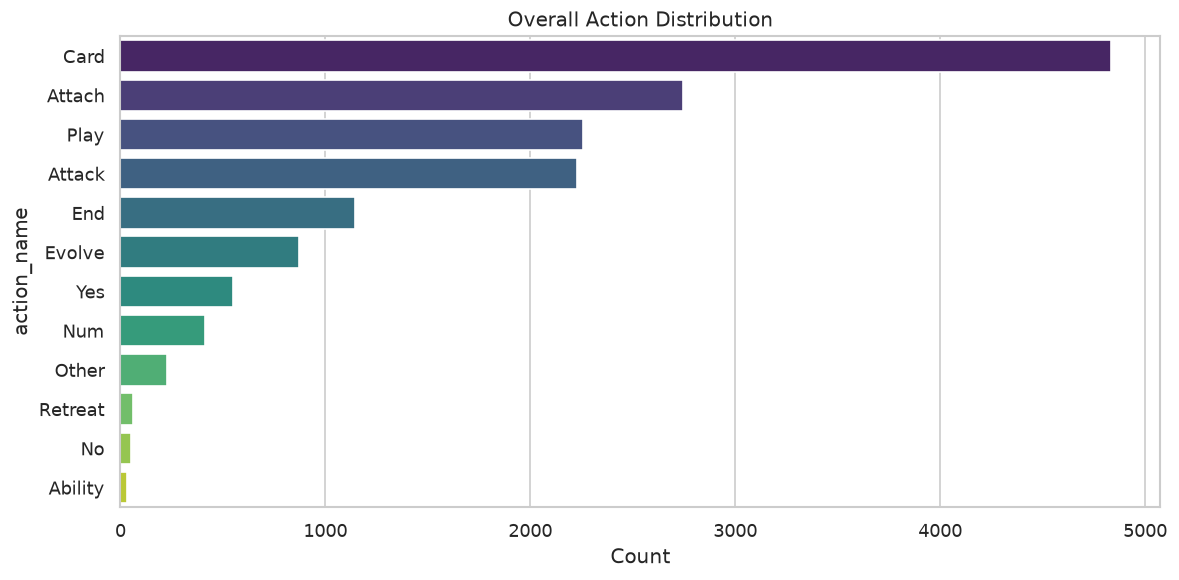

In [8]:
if frames is not None:
    OPT_NAMES = {
        0: "Num", 1: "Yes", 2: "No", 3: "Card", 7: "Play",
        8: "Attach", 9: "Evolve", 10: "Ability", 11: "Discard",
        12: "Retreat", 13: "Attack", 14: "End", 15: "Skill",
    }
    frames["action_name"] = frames["chosen_type"].map(OPT_NAMES).fillna("Other")

    counts = frames["action_name"].value_counts()
    plt.figure(figsize=(10, 5))
    sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette="viridis", legend=False)
    plt.xlabel("Count")
    plt.title("Overall Action Distribution")
    plt.tight_layout()
    plt.show()

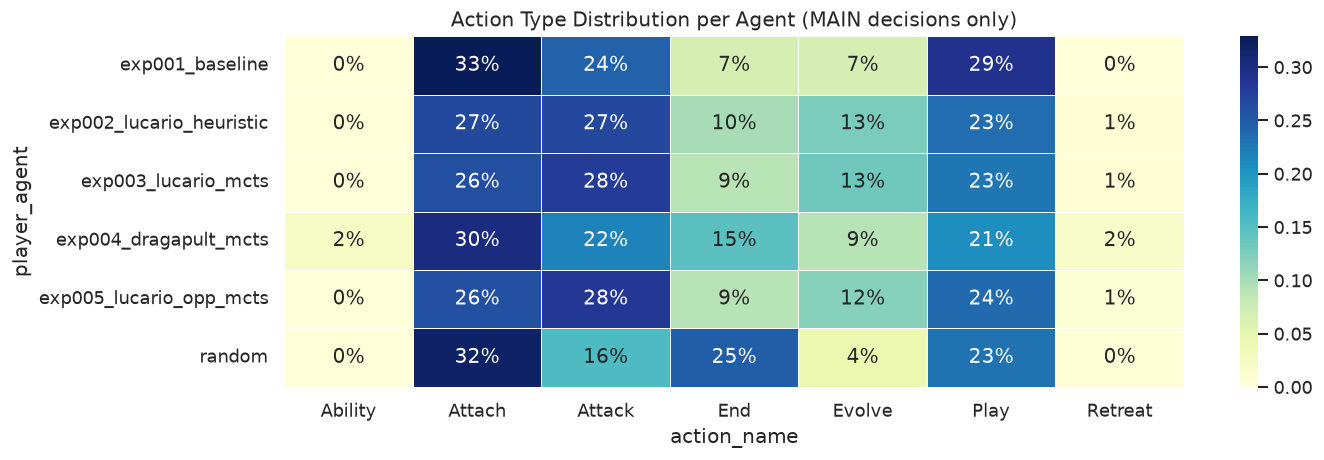

In [9]:
if frames is not None and results is not None:
    f = frames.merge(results[["match_id", "agent0", "agent1"]], on="match_id", how="left")
    f["player_agent"] = np.where(f["player"] == 0, f["agent0"], f["agent1"])

    main_actions = f[f["select_type"] == 0]
    action_by_agent = main_actions.groupby(["player_agent", "action_name"]).size().unstack(fill_value=0)
    action_pct = action_by_agent.div(action_by_agent.sum(axis=1), axis=0)

    plt.figure(figsize=(12, max(4, len(action_pct) * 0.4)))
    sns.heatmap(action_pct, annot=True, fmt=".0%", cmap="YlGnBu", linewidths=0.5)
    plt.title("Action Type Distribution per Agent (MAIN decisions only)")
    plt.tight_layout()
    plt.show()

---
## 4. Prize Race Dynamics

How does prize lead evolve over the course of a game?

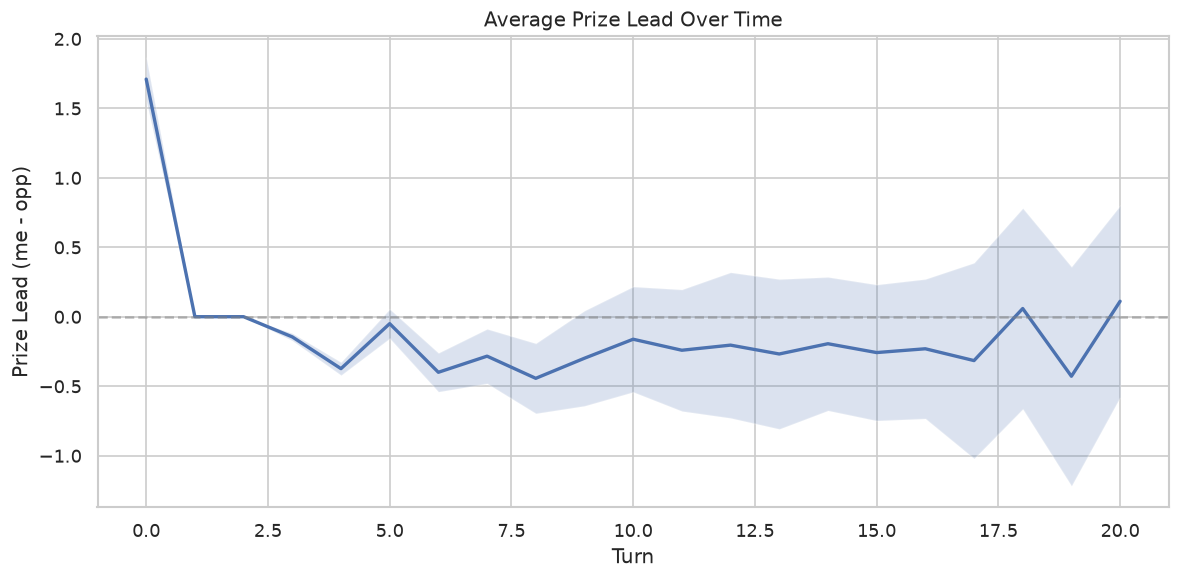

In [10]:
if turns is not None:
    turns["prize_lead"] = turns["me_prizes_taken"] - turns["opp_prizes_taken"]

    lead_by_turn = turns.groupby("turn")["prize_lead"].agg(["mean", "sem"])
    lead_by_turn = lead_by_turn[lead_by_turn.index <= 20]

    plt.figure(figsize=(10, 5))
    plt.plot(lead_by_turn.index, lead_by_turn["mean"], "b-", linewidth=2)
    plt.fill_between(
        lead_by_turn.index,
        lead_by_turn["mean"] - 1.96 * lead_by_turn["sem"],
        lead_by_turn["mean"] + 1.96 * lead_by_turn["sem"],
        alpha=0.2,
    )
    plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
    plt.xlabel("Turn")
    plt.ylabel("Prize Lead (me - opp)")
    plt.title("Average Prize Lead Over Time")
    plt.tight_layout()
    plt.show()

In [11]:
if turns is not None and results is not None:
    first_prize = turns[turns["prize_taken"]].copy()
    first_prize = first_prize.loc[first_prize.groupby("match_id")["turn"].idxmin()]
    fp = first_prize.merge(results[["match_id", "winner"]], on="match_id", how="left")
    fp["first_taker_won"] = (fp["player"] == fp["winner"]).astype(int)
    fp_wr = fp["first_taker_won"].mean()
    print(f"First-prize taker win rate: {fp_wr:.1%} ({fp['first_taker_won'].sum()}/{len(fp)})")

First-prize taker win rate: 100.0% (3/3)


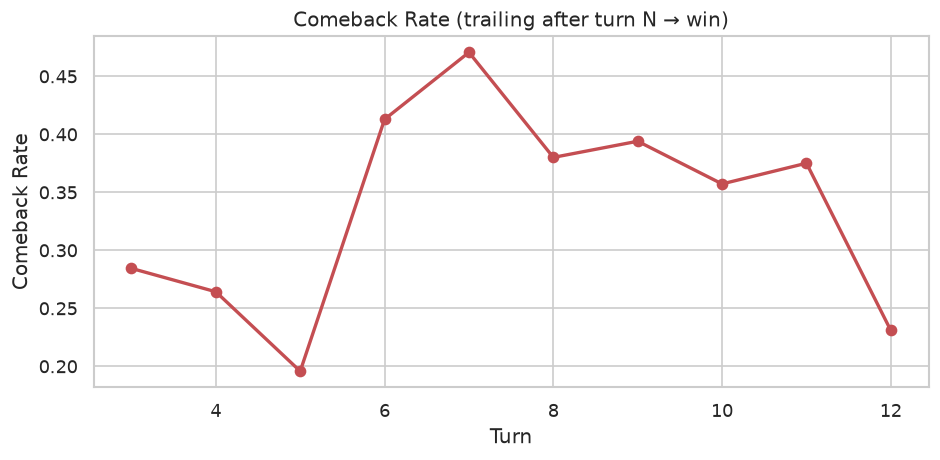

In [12]:
if turns is not None and results is not None:
    trail_counts = []
    for t in range(1, 13):
        trail = turns[turns["turn"] == t].copy()
        trail = trail.merge(results[["match_id", "winner"]], on="match_id", how="left")
        trail["trailing"] = trail["me_prizes_taken"] < trail["opp_prizes_taken"]
        trail["came_back"] = (trail["trailing"]) & (trail["player"] == trail["winner"])
        if len(trail) > 0 and trail["trailing"].sum() > 0:
            trail_counts.append({"turn": t, "comeback_rate": trail["came_back"].sum() / trail["trailing"].sum()})

    if trail_counts:
        cb = pd.DataFrame(trail_counts)
        plt.figure(figsize=(8, 4))
        plt.plot(cb["turn"], cb["comeback_rate"], "ro-", linewidth=2)
        plt.xlabel("Turn")
        plt.ylabel("Comeback Rate")
        plt.title("Comeback Rate (trailing after turn N \u2192 win)")
        plt.tight_layout()
        plt.show()

---
## 5. Turn & Game Length Analysis

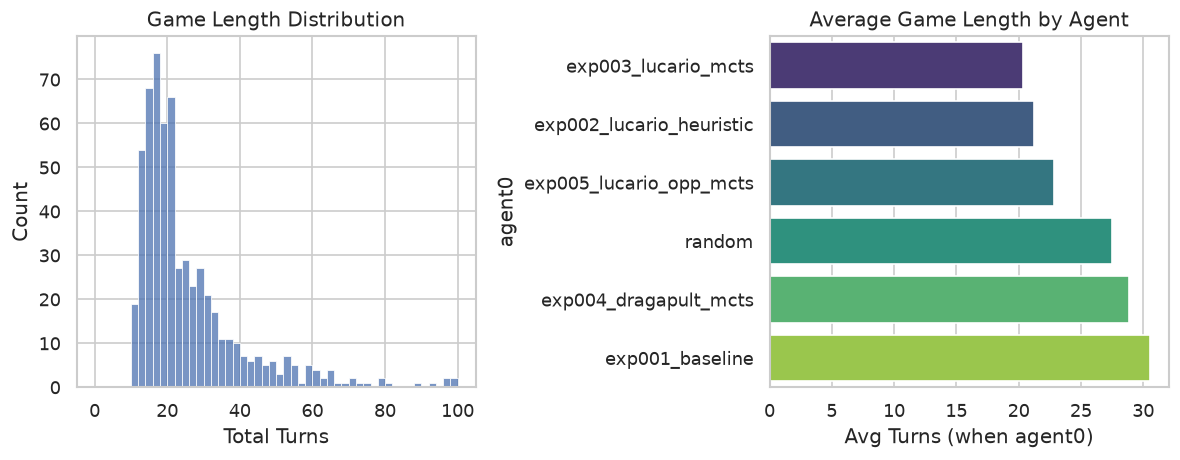

In [13]:
if results is not None:
    clean = results[results["winner"].isin([0, 1])]
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(clean["turns"], bins=range(0, clean["turns"].max() + 2, 2), kde=False)
    plt.xlabel("Total Turns")
    plt.title("Game Length Distribution")

    plt.subplot(1, 2, 2)
    by_agent = clean.groupby("agent0")["turns"].mean().sort_values()
    sns.barplot(x=by_agent.values, y=by_agent.index, hue=by_agent.index, palette="viridis", legend=False)
    plt.xlabel("Avg Turns (when agent0)")
    plt.title("Average Game Length by Agent")
    plt.tight_layout()
    plt.show()

---
## 6. First-Player Bias

In [14]:
if results is not None and "first_player" in results.columns:
    fp_wr = results.groupby("first_player")["winner"].apply(
        lambda x: (x == x.name).mean() if len(x) > 0 else 0
    )
    print("Win rate by first player:")
    print(fp_wr.to_string(float_format="{:+.1%}".format))
else:
    print("first_player not available in aggregated data yet")

first_player not available in aggregated data yet


---
## 7. Phase Detection

Compare agent behaviour across early (prizes 6-4), mid (3-2), and late (1-0) game.

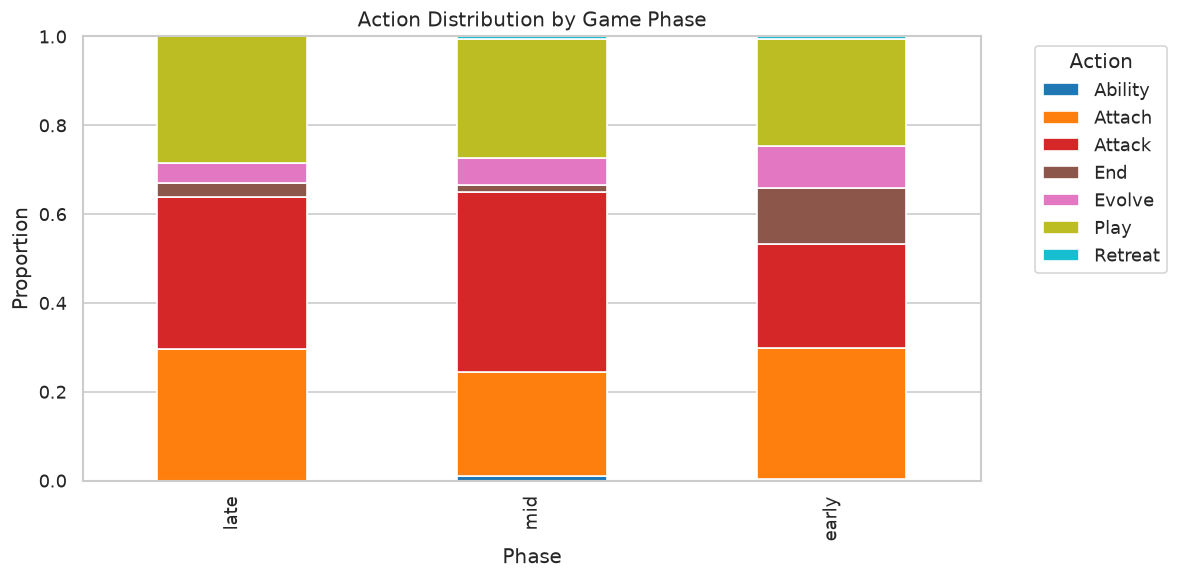

In [15]:
if frames is not None:
    f = frames.copy()
    f["phase"] = pd.cut(
        f["me_prize_remaining"],
        bins=[-1, 0, 2, 4, 6],
        labels=["knockout", "late", "mid", "early"],
    )

    phase_actions = f[f["select_type"] == 0].groupby(["phase", "action_name"]).size().unstack(fill_value=0)
    phase_pct = phase_actions.div(phase_actions.sum(axis=1), axis=0)

    plt.figure(figsize=(10, 5))
    phase_pct.plot(kind="bar", stacked=True, colormap="tab10", ax=plt.gca())
    plt.title("Action Distribution by Game Phase")
    plt.xlabel("Phase")
    plt.ylabel("Proportion")
    plt.legend(title="Action", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

---
## 8. Error Analysis

In [16]:
if results is not None:
    errors = results[results["error"].notna()]
    print(f"Matches with errors: {len(errors)} / {len(results)}")
    if len(errors) > 0:
        print(errors[["agent0", "agent1", "error"]].to_string())

Matches with errors: 1200 / 1800
                        agent0                    agent1             error
80                      random           exp005_deck_opt  'current_player'
81                      random           exp005_deck_opt  'current_player'
82                      random           exp005_deck_opt  'current_player'
83                      random           exp005_deck_opt  'current_player'
84                      random           exp005_deck_opt  'current_player'
85                      random           exp005_deck_opt  'current_player'
86                      random           exp005_deck_opt  'current_player'
87                      random           exp005_deck_opt  'current_player'
88                      random           exp005_deck_opt  'current_player'
89                      random           exp005_deck_opt  'current_player'
90                      random           exp005_deck_opt  'current_player'
91                      random           exp005_deck_opt  'current_

---
## 9. Decision Pattern Analysis

Dive into specific scenarios.

In [17]:
if frames is not None:
    main = frames[frames["select_type"] == 0].copy()
    decision_counts = main.groupby(["match_id", "turn", "player"]).size().reset_index(name="decisions")
    print(f"Mean decisions per turn-player: {decision_counts['decisions'].mean():.2f}")
    print(f"Max decisions in a turn: {decision_counts['decisions'].max()}")

    end_pct = (main["chosen_type"] == 14).mean()
    print(f"End (pass) decision rate: {end_pct:.1%}")

    attack_pct = (main["chosen_type"] == 13).mean()
    print(f"Attack decision rate: {attack_pct:.1%}")

    # Attack vs End by game phase
    main["phase"] = pd.cut(
        main["me_prize_remaining"],
        bins=[-1, 0, 2, 4, 6],
        labels=["knockout", "late", "mid", "early"],
    )
    phase_attack = main[main["chosen_type"].isin([13, 14])].groupby("phase")["chosen_type"].apply(
        lambda x: (x == 13).mean()
    )
    print(f"\nAttack rate by phase:\n{phase_attack.to_string(float_format='{:.1%}'.format)}")

Mean decisions per turn-player: 2.77
Max decisions in a turn: 8
End (pass) decision rate: 12.3%
Attack decision rate: 23.8%

Attack rate by phase:
phase
late    91.2%
mid     96.6%
early   64.9%


---
## Summary & Next Steps

Key questions to explore:
- Which archetypes have the best prize-race curves?
- What actions differentiate winning vs losing games?
- Are there decision patterns that correlate with first-player advantage?
- Can we identify a "stall" pattern (too many End actions in mid-game)?
- Which deck archetypes counter which in the current meta?